# La V1/V2 du modèle dans prod_notebook perf mieux que ce test_2 sur l'échantillon de 10M de lignes d'OCTOBRE 2019 -
## La diffence est le choix des catégories_codes gardés dans les features

In [118]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

import lightgbm as lgb


In [119]:
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 10_000_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_20645/1155051505.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 9 columns):
 #   Column         Dtype   
---  ------         -----   
 0   event_time     object  
 1   event_type     category
 2   product_id     int32   
 3   category_id    int64   
 4   category_code  category
 5   brand          category
 6   price          float32 
 7   user_id        int32   
 8   user_session   object  
dtypes: category(3), float32(1), int32(2), int64(1), object(2)
memory usage: 381.6+ MB


In [121]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
...,...,...,...,...,...,...,...,...,...
9999995,2019-10-08 17:26:09 UTC,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68
9999996,2019-10-08 17:26:09 UTC,view,32100001,2060237588744111062,NaN,NaN,164.100006,514437524,f8fc5c52-ae97-4a64-b6f4-fa3f5f9f28df
9999997,2019-10-08 17:26:09 UTC,view,26400265,2053013563651392361,NaN,lucente,154.190002,547749418,e22d0270-8dea-4cc1-ae99-e78a581f515e
9999998,2019-10-08 17:26:09 UTC,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096


In [122]:
# Verify temporal range
print(df['event_time'].min(), df['event_time'].max())

2019-10-01 00:00:00 UTC 2019-10-08 17:26:09 UTC


In [123]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.962782
cart        0.019935
purchase    0.017283
Name: proportion, dtype: float64

This specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.

In [124]:
df['category_id'].nunique()

566

In [125]:
df['product_id'].nunique()

121903

In [126]:
df['category_code'].nunique()

123

In [127]:
#Clean the event time, remove UTC

df["event_time"] = pd.to_datetime(
    df["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

In [128]:
# Stats descriptives (colonnes numériques)
df.describe()

,event_time,product_id,category_id,price,user_id
count,10000000,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
mean,2019-10-04 23:35:08.081178368,1.011534e+07,2.056684e+18,2.960614e+02,5.317569e+08
min,2019-10-01 00:00:00,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,2019-10-03 03:22:41,1.005115e+06,2.053014e+18,6.525000e+01,5.156193e+08
50%,2019-10-05 01:32:45,4.900087e+06,2.053014e+18,1.619100e+02,5.274672e+08
75%,2019-10-06 18:21:33,1.570007e+07,2.053014e+18,3.618200e+02,5.487683e+08
max,2019-10-08 17:26:09,5.560003e+07,2.175420e+18,2.574070e+03,5.581647e+08
std,NaN,1.124471e+07,1.681746e+16,3.669100e+02,1.715918e+07


In [129]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
brand,1388005,13.9
user_session,1,0.0


In [130]:
df['user_id'].nunique()

1070614

In [131]:
df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_20645/985662042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [132]:
df_purchase

category_code
accessories.bag         265
accessories.umbrella      8
accessories.wallet       54
apparel.belt              2
apparel.costume          25
                       ... 
sport.ski                 2
sport.snowboard           3
sport.tennis              0
sport.trainer            65
stationery.cartrige      19
Name: event_type, Length: 123, dtype: int64

In [133]:
df_purchase.sort_values(ascending=False)

category_code
electronics.smartphone           79205
electronics.audio.headphone       7257
electronics.video.tv              4849
electronics.clocks                4495
computers.notebook                3914
                                 ...  
country_yard.furniture.bench         0
country_yard.furniture.hammok        0
apparel.dress                        0
apparel.jacket                       0
sport.tennis                         0
Name: event_type, Length: 123, dtype: int64

In [134]:
(df_purchase / df_purchase.sum() * 100).sort_values(ascending=False)

category_code
electronics.smartphone           59.461428
electronics.audio.headphone       5.448035
electronics.video.tv              3.640281
electronics.clocks                3.374523
computers.notebook                2.938350
                                   ...    
country_yard.furniture.bench      0.000000
country_yard.furniture.hammok     0.000000
apparel.dress                     0.000000
apparel.jacket                    0.000000
sport.tennis                      0.000000
Name: event_type, Length: 123, dtype: float64

In [135]:
# Lister les catégories à 0 achats
df_purchase[df_purchase == 0].index.tolist()
# Combien il y en a
(df_purchase == 0).sum()

np.int64(7)

In [136]:
# Catégories avec au moins 1 achat
df_purchase_clean = df_purchase[df_purchase > 0].sort_values(ascending=False)
df_purchase_clean

category_code
electronics.smartphone         79205
electronics.audio.headphone     7257
electronics.video.tv            4849
electronics.clocks              4495
computers.notebook              3914
                               ...  
apparel.scarf                      2
apparel.shoes.sandals              2
apparel.shorts                     2
apparel.shoes.ballet_shoes         1
apparel.skirt                      1
Name: event_type, Length: 116, dtype: int64

In [137]:
df["brand"] = df["brand"].astype(str).replace("nan", "unknown").astype("category")
df["has_brand"] = (df["brand"] != "unknown").astype("int8")

In [138]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
user_session,1,0.0


In [139]:
df = df.drop_duplicates()

In [140]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1
...,...,...,...,...,...,...,...,...,...,...
9999995,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1
9999996,2019-10-08 17:26:09,view,32100001,2060237588744111062,NaN,unknown,164.100006,514437524,f8fc5c52-ae97-4a64-b6f4-fa3f5f9f28df,0
9999997,2019-10-08 17:26:09,view,26400265,2053013563651392361,NaN,lucente,154.190002,547749418,e22d0270-8dea-4cc1-ae99-e78a581f515e,1
9999998,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1


In [141]:
n_bad_price = (df["price"] <= 0).sum()

In [142]:
n_bad_price

np.int64(15522)

In [143]:
df["has_valid_price"] = (df["price"] > 0).astype("int8")

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_20645/3154629573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["has_valid_price"] = (df["price"] > 0).astype("int8")


In [144]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1,1
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9999995,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1,1
9999996,2019-10-08 17:26:09,view,32100001,2060237588744111062,NaN,unknown,164.100006,514437524,f8fc5c52-ae97-4a64-b6f4-fa3f5f9f28df,0,1
9999997,2019-10-08 17:26:09,view,26400265,2053013563651392361,NaN,lucente,154.190002,547749418,e22d0270-8dea-4cc1-ae99-e78a581f515e,1,1
9999998,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1,1


# Preprocessing X

### On garde catégorie code mais on filtre par catégories sélectionnées (électronique)

In [168]:
selected_categories = df[
df['category_code'].str.contains('electronics|computers|appliances', na=False)
]['category_code'].value_counts().index

selected_categories

CategoricalIndex(['electronics.smartphone', 'electronics.clocks',
                  'computers.notebook', 'electronics.audio.headphone',
                  'electronics.video.tv', 'appliances.kitchen.refrigerators',
                  'appliances.kitchen.washer', 'appliances.environment.vacuum',
                  'electronics.audio.subwoofer', 'computers.desktop',
                  ...
                  'auto.accessories.winch', 'apparel.tshirt',
                  'auto.accessories.videoregister', 'auto.accessories.radar',
                  'auto.accessories.player', 'auto.accessories.parktronic',
                  'auto.accessories.compressor', 'auto.accessories.alarm',
                  'apparel.underwear', 'stationery.cartrige'],
                 categories=['accessories.bag', 'accessories.umbrella', 'accessories.wallet', 'apparel.belt', ..., 'sport.snowboard', 'sport.tennis', 'sport.trainer', 'stationery.cartrige'], ordered=False, dtype='category', name='category_code', length=123)

In [169]:
X = df[df['category_code'].isin(selected_categories)]

In [170]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
5,2019-10-01 00:00:05,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9999989,2019-10-08 17:26:08,view,1004433,2053013555631882655,electronics.smartphone,samsung,257.149994,512963963,b61ab7c6-2a1a-4ef2-9e1d-1fa9b288fe9b,1,1
9999990,2019-10-08 17:26:09,view,17200778,2053013559792632471,furniture.living_room.sofa,unknown,494.200012,539329932,a527600d-ca43-4354-94a7-db19bb025084,0,1
9999995,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1,1
9999998,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1,1


In [171]:
X = X.drop_duplicates()

In [149]:
# Il reste 38% des lignes, donc 1/3 des events sont compris sur ces 5 catégories

In [173]:
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
user_session,1,0.0


In [174]:
X = X.sort_values("event_time").reset_index(drop=True)

In [175]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
1,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
2,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
3,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
4,2019-10-01 00:00:05,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9,1,1
...,...,...,...,...,...,...,...,...,...,...,...
6770312,2019-10-08 17:26:08,view,6902272,2053013560312726199,furniture.living_room.chair,zlatek,51.459999,515096468,f4948c93-bc9c-0ef7-3899-506917d9968f,1,1
6770313,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1,1
6770314,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1,1
6770315,2019-10-08 17:26:09,view,17200778,2053013559792632471,furniture.living_room.sofa,unknown,494.200012,539329932,a527600d-ca43-4354-94a7-db19bb025084,0,1


In [176]:
observation_end = pd.Timestamp("2019-10-06")
prediction_end  = pd.Timestamp("2019-10-09")

In [177]:
X_obs = X[X["event_time"] < observation_end].copy()

X_pred = X[X["event_time"] >= observation_end].copy()

In [178]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
1,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
2,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
3,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
4,2019-10-01 00:00:05,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4344197,2019-10-05 23:59:55,view,1306556,2053013558920217191,computers.notebook,lenovo,926.640015,513465266,8576dd95-91d5-47c3-aa50-6220118fbd38,1,1
4344198,2019-10-05 23:59:55,view,44300024,2100825583029060150,apparel.jeans,unknown,46.080002,557193392,80192c3c-637c-495e-aef7-5ad848989340,0,1
4344199,2019-10-05 23:59:57,view,6400313,2053013554121933129,computers.components.cpu,intel,177.479996,546038044,b8338d61-1101-4817-88dc-b29f00ca355c,1,1
4344200,2019-10-05 23:59:58,view,4501043,2053013563877884791,appliances.kitchen.hob,hansa,205.410004,515945416,ccc1c808-4f60-406f-a6da-a8742ce4d6ba,1,1


In [179]:
X_pred

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
4344202,2019-10-06 00:00:00,view,6200524,2053013552293216471,appliances.environment.air_heater,tefal,79.800003,518777004,2c3d17d6-bb80-47ba-8fe2-f057f9a474a6,1,1
4344203,2019-10-06 00:00:00,cart,1005116,2053013555631882655,electronics.smartphone,apple,1052.790039,557192362,3e516ca1-29d2-4ef0-96bb-d1fdaac62d08,1,1
4344204,2019-10-06 00:00:00,view,1005014,2053013555631882655,electronics.smartphone,samsung,603.619995,519093005,e0444ad7-cd5b-4501-8d09-b031a26ba67f,1,1
4344205,2019-10-06 00:00:01,cart,1004836,2053013555631882655,electronics.smartphone,samsung,230.589996,556720959,d1b1bd63-936c-49d4-b891-f7e08a416297,1,1
4344206,2019-10-06 00:00:02,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,518895065,68a21481-6b44-4e72-8ea1-07ad6099a8d4,1,1
...,...,...,...,...,...,...,...,...,...,...,...
6770312,2019-10-08 17:26:08,view,6902272,2053013560312726199,furniture.living_room.chair,zlatek,51.459999,515096468,f4948c93-bc9c-0ef7-3899-506917d9968f,1,1
6770313,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1,1
6770314,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1,1
6770315,2019-10-08 17:26:09,view,17200778,2053013559792632471,furniture.living_room.sofa,unknown,494.200012,539329932,a527600d-ca43-4354-94a7-db19bb025084,0,1


In [180]:
purchasers = set(X_pred.loc[X_pred["event_type"] == "purchase", "user_id"])


In [181]:
len(purchasers)

31880

In [182]:
y_purchasers = pd.DataFrame({"user_id": X_obs["user_id"].unique()})
y_purchasers["label"] = y_purchasers["user_id"].isin(purchasers).astype(int)

In [183]:
y_purchasers["label"].value_counts()
# Sur X_obs, env. 2 500 000 events sont enregistrés pour 375 000 utilisateurs unique, avec 9300 qui achèteront sur l'intervalle d'observation

label
0    555702
1     14001
Name: count, dtype: int64

In [184]:
y_purchasers

,user_id,label
0,554748717,0
1,519107250,0
2,550050854,0
3,535871217,0
4,512742880,0
...,...,...
569698,513179882,0
569699,557194015,0
569700,557193245,0
569701,552859242,0


# Feature engineering X_obs

In [185]:
X_obs["hour"] = X_obs["event_time"].dt.hour
X_obs["dayofweek"] = X_obs["event_time"].dt.dayofweek  # 0=Lundi
X_obs["is_weekend"] = (X_obs["dayofweek"] >= 5).astype("int8")


In [186]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price,hour,dayofweek,is_weekend
0,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1,0,1,0
1,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1,0,1,0
2,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1,0,1,0
3,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1,0,1,0
4,2019-10-01 00:00:05,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4344197,2019-10-05 23:59:55,view,1306556,2053013558920217191,computers.notebook,lenovo,926.640015,513465266,8576dd95-91d5-47c3-aa50-6220118fbd38,1,1,23,5,1
4344198,2019-10-05 23:59:55,view,44300024,2100825583029060150,apparel.jeans,unknown,46.080002,557193392,80192c3c-637c-495e-aef7-5ad848989340,0,1,23,5,1
4344199,2019-10-05 23:59:57,view,6400313,2053013554121933129,computers.components.cpu,intel,177.479996,546038044,b8338d61-1101-4817-88dc-b29f00ca355c,1,1,23,5,1
4344200,2019-10-05 23:59:58,view,4501043,2053013563877884791,appliances.kitchen.hob,hansa,205.410004,515945416,ccc1c808-4f60-406f-a6da-a8742ce4d6ba,1,1,23,5,1


In [187]:
behavior = X_obs.groupby("user_id").agg(
    total_events   = ("event_type", "count"),
    total_views    = ("event_type", lambda x: (x == "view").sum()),
    total_carts    = ("event_type", lambda x: (x == "cart").sum()),
    total_purchases= ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions     = ("user_session", "nunique"),
    n_days_active  = ("event_time", lambda x: x.dt.date.nunique()),
)

# Features de comportement dans l'intervalle d'observation choisi
# Prend beaucoup de temps les fonctions lambda, optimisable?

In [188]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active
user_id,,,,,,
184265397,4,4,0,0,1,1
208669541,1,1,0,0,1,1
239475080,1,1,0,0,1,1
240522111,2,2,0,0,2,1
241587569,1,1,0,0,1,1
...,...,...,...,...,...,...
557193489,1,1,0,0,1,1
557193619,1,1,0,0,1,1
557193760,4,4,0,0,1,1


In [189]:
behavior["has_ever_carted"] = (behavior["total_carts"] > 0).astype("int8")
behavior["has_ever_purchased"] = (behavior["total_purchases"] > 0).astype("int8")


In [190]:
behavior["has_ever_carted"].value_counts(normalize=True)

has_ever_carted
0    0.906743
1    0.093257
Name: proportion, dtype: float64

In [191]:
behavior["has_ever_purchased"].value_counts(normalize=True)

has_ever_purchased
0    0.907604
1    0.092396
Name: proportion, dtype: float64

In [192]:
behavior["view_to_cart_ratio"] = (
    behavior["total_carts"] / behavior["total_views"].replace(0, 1)
)
behavior["cart_to_purchase_ratio"] = (
    behavior["total_purchases"] / behavior["total_carts"].replace(0, 1)
)

#Est-ce que c'est des bonnes features? L'info est peut-être déjà présente

In [193]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio
user_id,,,,,,,,,,
184265397,4,4,0,0,1,1,0,0,0.0,0.0
208669541,1,1,0,0,1,1,0,0,0.0,0.0
239475080,1,1,0,0,1,1,0,0,0.0,0.0
240522111,2,2,0,0,2,1,0,0,0.0,0.0
241587569,1,1,0,0,1,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
557193489,1,1,0,0,1,1,0,0,0.0,0.0
557193619,1,1,0,0,1,1,0,0,0.0,0.0
557193760,4,4,0,0,1,1,0,0,0.0,0.0


In [194]:
behavior["cart_to_purchase_ratio"].value_counts(ascending=False)

cart_to_purchase_ratio
0.000000    517065
1.000000     32213
0.500000      5177
2.000000      4597
0.333333      2103
             ...  
1.050000         1
6.666667         1
1.315789         1
3.800000         1
0.560000         1
Name: count, Length: 283, dtype: int64

# Features de session 

In [195]:
session_stats = X_obs.groupby(["user_id", "user_session"], as_index=False).agg(
    session_start = ("event_time", "min"),
    session_end   = ("event_time", "max"),
    session_events = ("event_time", "count"),
)

In [196]:
session_stats

,user_id,user_session,session_start,session_end,session_events
0,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247,2019-10-04 17:44:37,2019-10-04 17:51:04,4
1,208669541,610cbaff-9d41-4fa9-a94a-ccb9cc1f30a4,2019-10-04 05:49:14,2019-10-04 05:49:14,1
2,239475080,9ede5a85-c3f8-4948-bfd0-d5f1d0420c60,2019-10-05 18:20:26,2019-10-05 18:20:26,1
3,240522111,b74568ee-fd16-4538-943c-0f2718b87fba,2019-10-05 12:34:23,2019-10-05 12:34:23,1
4,240522111,cc654a5b-e561-4e6b-83aa-9b450a4f633c,2019-10-05 09:07:30,2019-10-05 09:07:30,1
...,...,...,...,...,...
997785,557193489,41988c90-65a9-412d-9b46-fb9965ee1b9f,2019-10-05 23:53:11,2019-10-05 23:53:11,1
997786,557193619,c7d4167a-6a0b-4449-8a64-d32b0e47e0e1,2019-10-05 23:54:25,2019-10-05 23:54:25,1
997787,557193760,fdc7f7ca-10dc-467d-a963-8a65397bf4e6,2019-10-05 23:57:44,2019-10-05 23:58:21,4
997788,557193936,2c12f12d-93b8-4831-bcc5-bea36afc8f8a,2019-10-05 23:58:21,2019-10-05 23:58:43,2


In [197]:
session_stats["user_id"].nunique()
# Environ 2 sessions par user_id

569703

In [198]:
session_stats["session_duration"] = (
    session_stats["session_end"] - session_stats["session_start"]
)

In [199]:
session_stats

,user_id,user_session,session_start,session_end,session_events,session_duration
0,184265397,2c5d0468-32e1-42f7-9b4e-b17c1d387247,2019-10-04 17:44:37,2019-10-04 17:51:04,4,0 days 00:06:27
1,208669541,610cbaff-9d41-4fa9-a94a-ccb9cc1f30a4,2019-10-04 05:49:14,2019-10-04 05:49:14,1,0 days 00:00:00
2,239475080,9ede5a85-c3f8-4948-bfd0-d5f1d0420c60,2019-10-05 18:20:26,2019-10-05 18:20:26,1,0 days 00:00:00
3,240522111,b74568ee-fd16-4538-943c-0f2718b87fba,2019-10-05 12:34:23,2019-10-05 12:34:23,1,0 days 00:00:00
4,240522111,cc654a5b-e561-4e6b-83aa-9b450a4f633c,2019-10-05 09:07:30,2019-10-05 09:07:30,1,0 days 00:00:00
...,...,...,...,...,...,...
997785,557193489,41988c90-65a9-412d-9b46-fb9965ee1b9f,2019-10-05 23:53:11,2019-10-05 23:53:11,1,0 days 00:00:00
997786,557193619,c7d4167a-6a0b-4449-8a64-d32b0e47e0e1,2019-10-05 23:54:25,2019-10-05 23:54:25,1,0 days 00:00:00
997787,557193760,fdc7f7ca-10dc-467d-a963-8a65397bf4e6,2019-10-05 23:57:44,2019-10-05 23:58:21,4,0 days 00:00:37
997788,557193936,2c12f12d-93b8-4831-bcc5-bea36afc8f8a,2019-10-05 23:58:21,2019-10-05 23:58:43,2,0 days 00:00:22


## Session duration exploration

In [200]:
durations_sess = session_stats["session_duration"]

In [201]:
durations_sess.sort_values(ascending=False)

768465   4 days 15:51:15
799974   4 days 14:59:08
733883   4 days 14:24:53
441276   4 days 14:06:16
807160   4 days 13:38:22
               ...      
724738   0 days 00:00:00
724737   0 days 00:00:00
445756   0 days 00:00:00
204509   0 days 00:00:00
997789   0 days 00:00:00
Name: session_duration, Length: 997790, dtype: timedelta64[ns]

In [202]:
durations_sess.describe()

count                       997790
mean     0 days 00:10:58.036077731
std      0 days 02:08:36.876130747
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:01:01
75%                0 days 00:04:14
max                4 days 15:51:15
Name: session_duration, dtype: object

In [203]:
crazy_duration = durations_sess[durations_sess > "1 days"]

In [204]:
crazy_duration
# A supprimer des prochaines itérations du modèle après baseline?

30       1 days 14:56:55
63       2 days 12:15:52
184      1 days 00:00:15
273      2 days 00:57:39
322      1 days 01:03:37
               ...      
951803   1 days 04:14:10
952629   1 days 03:52:33
954281   1 days 00:50:35
956957   1 days 03:07:15
958818   1 days 02:25:02
Name: session_duration, Length: 1535, dtype: timedelta64[ns]

In [205]:
# INfos de session par user_ID sur l'intervalle d'observation

session_user = session_stats.groupby("user_id").agg(
    avg_session_duration    = ("session_duration", "mean"),
    median_session_duration = ("session_duration", "median"),
    max_session_duration    = ("session_duration", "max"),
    avg_events_per_session  = ("session_events", "mean"),
    max_events_per_session  = ("session_events", "max"),
)
session_user

,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,
184265397,0 days 00:06:27,0 days 00:06:27,0 days 00:06:27,4.0,4
208669541,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
239475080,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
240522111,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
241587569,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...
557193489,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193619,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193760,0 days 00:00:37,0 days 00:00:37,0 days 00:00:37,4.0,4


## Assemblage Features

In [206]:
user_features = (behavior.join(session_user, how="left")
)

In [207]:
user_features

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,,,,,,,,,,,
184265397,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:06:27,0 days 00:06:27,0 days 00:06:27,4.0,4
208669541,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
239475080,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
240522111,2,2,0,0,2,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
241587569,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557193489,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193619,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193760,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:00:37,0 days 00:00:37,0 days 00:00:37,4.0,4


In [208]:
user_features.isna().sum()

total_events               0
total_views                0
total_carts                0
total_purchases            0
n_sessions                 0
n_days_active              0
has_ever_carted            0
has_ever_purchased         0
view_to_cart_ratio         0
cart_to_purchase_ratio     0
avg_session_duration       0
median_session_duration    0
max_session_duration       0
avg_events_per_session     0
max_events_per_session     0
dtype: int64

In [209]:
dataset = y_purchasers.merge(user_features, on="user_id", how="inner")

In [210]:
dataset

,user_id,label,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,554748717,0,3,3,0,0,2,1,0,0,0.0,0.0,0 days 00:00:30,0 days 00:00:30,0 days 00:01:00,1.500000,2
1,519107250,0,4,4,0,0,3,1,0,0,0.0,0.0,0 days 00:00:17.666666666,0 days 00:00:00,0 days 00:00:53,1.333333,2
2,550050854,0,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.000000,7
3,535871217,0,26,26,0,0,3,2,0,0,0.0,0.0,0 days 00:04:12,0 days 00:02:41,0 days 00:09:16,8.666667,16
4,512742880,0,50,48,0,2,11,4,0,1,0.0,2.0,0 days 00:02:13.545454545,0 days 00:02:38,0 days 00:03:58,4.545455,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569698,513179882,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569699,557194015,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569700,557193245,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569701,552859242,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1


In [211]:
X = dataset.drop(columns="label")

In [212]:
X

,user_id,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,554748717,3,3,0,0,2,1,0,0,0.0,0.0,0 days 00:00:30,0 days 00:00:30,0 days 00:01:00,1.500000,2
1,519107250,4,4,0,0,3,1,0,0,0.0,0.0,0 days 00:00:17.666666666,0 days 00:00:00,0 days 00:00:53,1.333333,2
2,550050854,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.000000,7
3,535871217,26,26,0,0,3,2,0,0,0.0,0.0,0 days 00:04:12,0 days 00:02:41,0 days 00:09:16,8.666667,16
4,512742880,50,48,0,2,11,4,0,1,0.0,2.0,0 days 00:02:13.545454545,0 days 00:02:38,0 days 00:03:58,4.545455,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569698,513179882,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569699,557194015,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569700,557193245,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1
569701,552859242,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.000000,1


In [213]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569703 entries, 0 to 569702
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   user_id                  569703 non-null  int32          
 1   total_events             569703 non-null  int64          
 2   total_views              569703 non-null  int64          
 3   total_carts              569703 non-null  int64          
 4   total_purchases          569703 non-null  int64          
 5   n_sessions               569703 non-null  int64          
 6   n_days_active            569703 non-null  int64          
 7   has_ever_carted          569703 non-null  int8           
 8   has_ever_purchased       569703 non-null  int8           
 9   view_to_cart_ratio       569703 non-null  float64        
 10  cart_to_purchase_ratio   569703 non-null  float64        
 11  avg_session_duration     569703 non-null  timedelta64[ns]
 12  me

In [214]:
for col in ["avg_session_duration", "median_session_duration", "max_session_duration"]:
    X[col] = X[col].dt.total_seconds()

In [215]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569703 entries, 0 to 569702
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  569703 non-null  int32  
 1   total_events             569703 non-null  int64  
 2   total_views              569703 non-null  int64  
 3   total_carts              569703 non-null  int64  
 4   total_purchases          569703 non-null  int64  
 5   n_sessions               569703 non-null  int64  
 6   n_days_active            569703 non-null  int64  
 7   has_ever_carted          569703 non-null  int8   
 8   has_ever_purchased       569703 non-null  int8   
 9   view_to_cart_ratio       569703 non-null  float64
 10  cart_to_purchase_ratio   569703 non-null  float64
 11  avg_session_duration     569703 non-null  float64
 12  median_session_duration  569703 non-null  float64
 13  max_session_duration     569703 non-null  float64
 14  avg_

In [216]:
X = X.astype("float32")

In [217]:
X = X.drop(columns="user_id")

In [218]:
X

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,30.000000,30.0,60.0,1.500000,2.0
1,4.0,4.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,17.666666,0.0,53.0,1.333333,2.0
2,7.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,196.000000,196.0,196.0,7.000000,7.0
3,26.0,26.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,252.000000,161.0,556.0,8.666667,16.0
4,50.0,48.0,0.0,2.0,11.0,4.0,0.0,1.0,0.0,2.0,133.545456,158.0,238.0,4.545455,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569698,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.0
569699,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.0
569700,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.0
569701,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,1.0


In [219]:
y = dataset["label"]
y

0         0
1         0
2         0
3         0
4         0
         ..
569698    0
569699    0
569700    0
569701    0
569702    0
Name: label, Length: 569703, dtype: int64

In [220]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [221]:
X_test

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
510837,5.0,5.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,164.0,164.0,164.0,2.5,3.0
547595,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
193574,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,68.0,68.0,68.0,2.0,2.0
462752,4.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,317.0,317.0,317.0,4.0,4.0
567575,8.0,8.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,469.0,469.0,469.0,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153772,6.0,6.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,83.0,32.0,217.0,2.0,3.0
319578,11.0,11.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,461.0,461.0,461.0,11.0,11.0
226220,2.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
190057,7.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,0.2,1.0,267.0,267.0,267.0,7.0,7.0


In [222]:
print(X_train.index[:5])
print(y_train.index[:5])

Index([418528, 364934, 470430, 51115, 436568], dtype='int64')
Index([418528, 364934, 470430, 51115, 436568], dtype='int64')


In [223]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
base_spw
# Combien de fois les non acheteurs sont présents de plus que les acheteurs

np.float64(39.68940273189894)

In [224]:
model_lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)

In [225]:
model_lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [226]:
#model_lgbm.predict()
#Ajuster le threshold de proba après la baseline? En utilisant model.predict_proba plutôt

In [227]:
y_test_proba = model_lgbm.predict_proba(X_test)[:, 1]

y_test_pred  = (y_test_proba >= 0.5).astype(int)
#Permet d'ajuster le seuil de probabilité de classification

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

In [228]:
roc_auc


0.7451101030608481

In [229]:
pr_auc

0.16059290528633263

In [230]:
y_test_proba

array([0.38011109, 0.21439494, 0.33412477, ..., 0.36793799, 0.76806914,
       0.21439494], shape=(113941,))

In [231]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_test_pred)
recall

0.5432142857142858

## Add Standardisation

In [232]:
pipeline = make_pipeline(
    StandardScaler(),
    model_lgbm
)

pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('lgbmclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1


In [233]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [234]:
roc_auc = roc_auc_score(y_test, y_test_proba)

In [235]:
roc_auc


0.7450274442246464

In [236]:
pr_auc = average_precision_score(y_test, y_test_proba)

In [237]:
pr_auc


0.1600786974625396

## Learning Curves ROC AUC

In [238]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

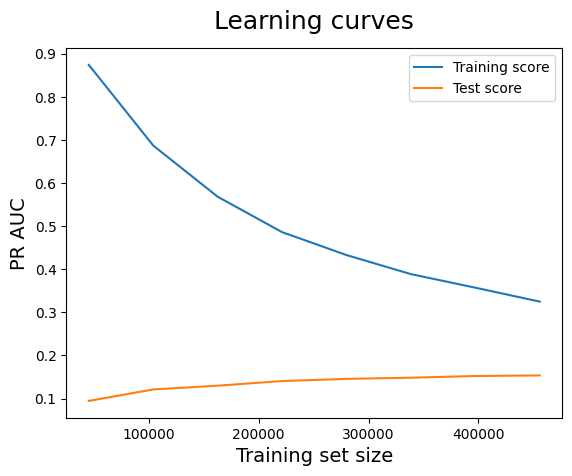

In [239]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

## Grid Search 

In [240]:
from sklearn.model_selection import RandomizedSearchCV


In [241]:
param_dist = {
    "n_estimators": np.arange(100, 600, 100),
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "num_leaves": np.arange(20, 150, 10),
    "max_depth": [-1, 5, 10, 15]
}

search = RandomizedSearchCV(
    model_lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'num_leaves': np.int64(40), 'n_estimators': np.int64(200), 'max_depth': 5, 'learning_rate': np.float64(0.04)}


In [242]:
model_lgbm_v2 = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    num_leaves=40,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.04
)

In [243]:
model_lgbm_v2.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,40
,max_depth,5
,learning_rate,0.04
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [244]:
y_test_proba_2 = model_lgbm_v2.predict_proba(X_test)[:, 1]
y_test_pred_2  = (y_test_proba_2 >= 0.5).astype(int)

In [245]:
roc_auc_2 = roc_auc_score(y_test, y_test_proba_2)
pr_auc_2  = average_precision_score(y_test, y_test_proba_2)

In [246]:
roc_auc_2

0.7838951036456908

In [247]:
pr_auc_2

0.1853441263366911

In [248]:
recall_2 = recall_score(y_test, y_test_pred_2)
recall_2

0.6542857142857142

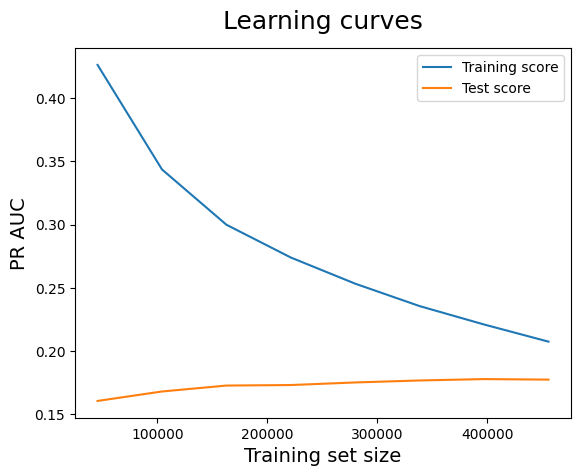

In [249]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm_v2,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()